In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression


from sklearn.model_selection import train_test_split

In [121]:
df=pd.read_csv('sales.csv')
df.head(5)

,order_id,date,region,product,category,customer_type,quantity,price,discount,sales
0,1,2024-04-12,East,Laptop,Electronics,Returning,8,590,0.09,4295.20
1,2,2024-12-14,South,Monitor,Accessories,Returning,2,262,0.18,429.68
2,3,2024-09-27,North,Phone,Accessories,New,5,512,0.09,2329.60
3,4,2024-04-16,West,Mouse,Electronics,Returning,1,485,0.09,441.35
4,5,2024-03-12,West,Phone,Electronics,Returning,7,332,0.22,1812.72


In [122]:

# preview data
df.head()

,order_id,date,region,product,category,customer_type,quantity,price,discount,sales
0,1,2024-04-12,East,Laptop,Electronics,Returning,8,590,0.09,4295.20
1,2,2024-12-14,South,Monitor,Accessories,Returning,2,262,0.18,429.68
2,3,2024-09-27,North,Phone,Accessories,New,5,512,0.09,2329.60
3,4,2024-04-16,West,Mouse,Electronics,Returning,1,485,0.09,441.35
4,5,2024-03-12,West,Phone,Electronics,Returning,7,332,0.22,1812.72


In [123]:

# dataset info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       500 non-null    int64  
 1   date           500 non-null    object 
 2   region         500 non-null    object 
 3   product        500 non-null    object 
 4   category       500 non-null    object 
 5   customer_type  500 non-null    object 
 6   quantity       500 non-null    int64  
 7   price          500 non-null    int64  
 8   discount       500 non-null    float64
 9   sales          500 non-null    float64
dtypes: float64(2), int64(3), object(5)
memory usage: 39.2+ KB


In [124]:

# summary statistics
df.describe()

,order_id,quantity,price,discount,sales
count,500.000000,500.000000,500.000000,500.00000,500.000000
mean,250.500000,4.968000,768.158000,0.14666,3333.059560
std,144.481833,2.569081,404.010497,0.08612,2693.185995
min,1.000000,1.000000,50.000000,0.00000,67.320000
25%,125.750000,3.000000,432.750000,0.08000,1120.867500
50%,250.500000,5.000000,742.000000,0.15000,2582.805000
75%,375.250000,7.000000,1094.500000,0.22000,4998.030000
max,500.000000,9.000000,1499.000000,0.30000,12700.800000


In [125]:
df.drop(columns=["discount","order_id"], inplace=True, errors="ignore")

In [126]:
df["date"] = pd.to_datetime(df["date"])

In [127]:
print(df.isnull().sum())

date             0
region           0
product          0
category         0
customer_type    0
quantity         0
price            0
sales            0
dtype: int64


In [128]:
df.duplicated().sum()

np.int64(0)

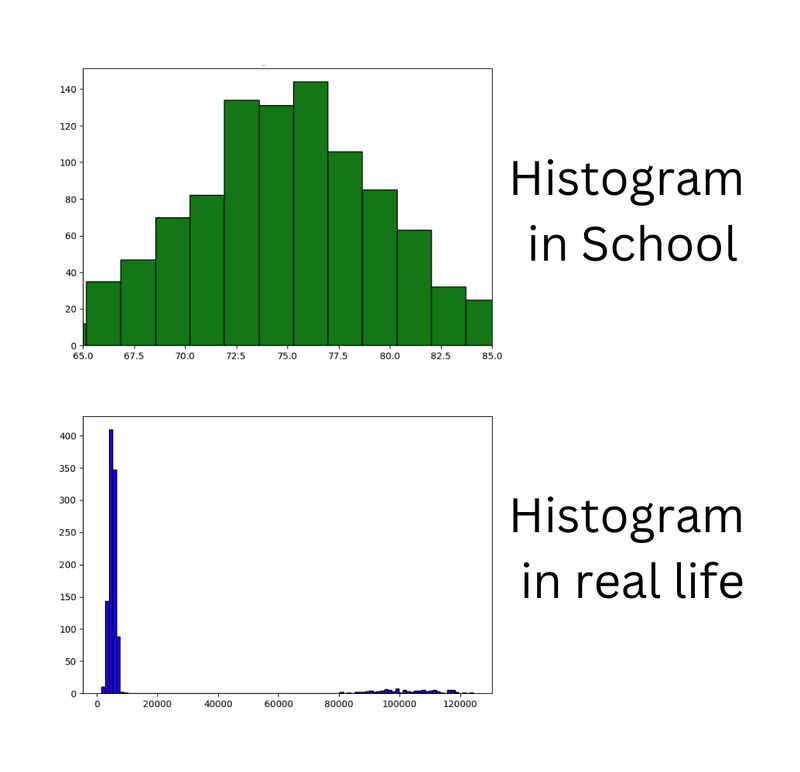

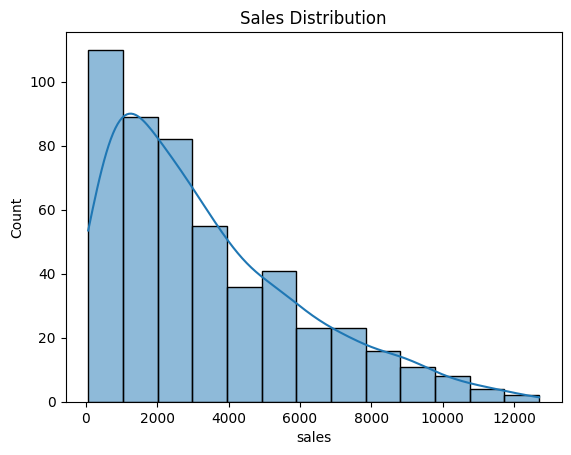

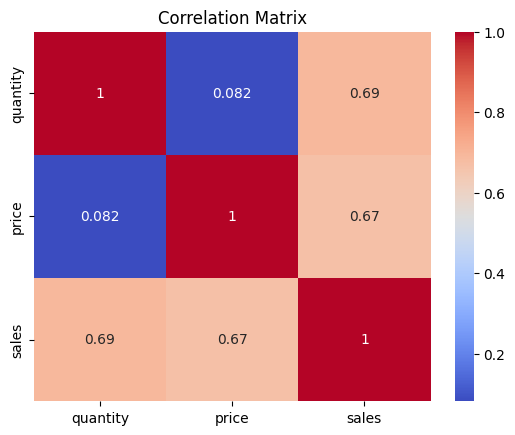

In [129]:
# sales distribution
sns.histplot(df["sales"], kde=True)
plt.title("Sales Distribution")
plt.show()

# correlation heatmap
numeric_df = df.select_dtypes(include=['int64','float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

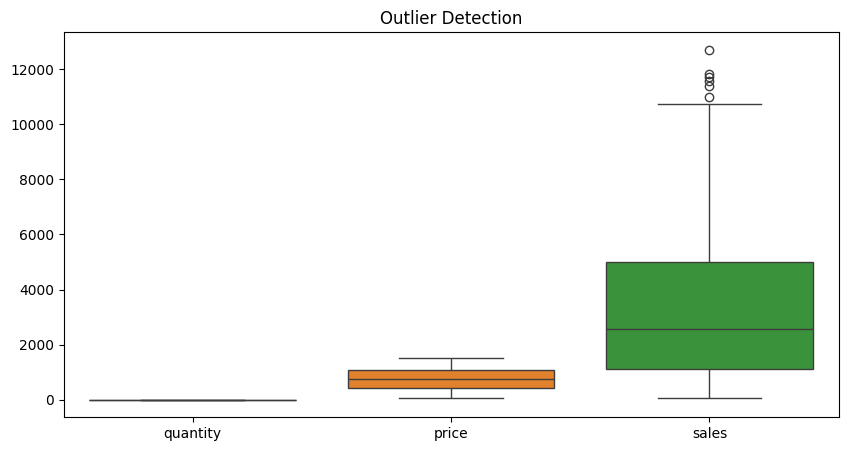

In [130]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df[['quantity','price','sales']])

plt.title("Outlier Detection")
plt.show()

In [131]:
# Calculate first quartile (25%)
Q1 = df['sales'].quantile(0.25)

# Calculate third quartile (75%)
Q3 = df['sales'].quantile(0.75)

# Calculate Interquartile Range
IQR = Q3 - Q1

# Define lower and upper limits for outliers
lower_limit = Q1 - 1.0 * IQR  #1.5 repersent Standard outlier detection increase or decrees csz extreme or too many values removed
upper_limit = Q3 + 1.0 * IQR

# Remove rows where sales value is outside the limits
df_clean = df[(df['sales'] >= lower_limit) & (df['sales'] <= upper_limit)]

# Print number of rows after removing outliers
print("Rows after removing outliers:", len(df_clean))

Rows after removing outliers: 476


In [148]:


# Detect outliers
outliers = df[(df['sales'] < lower_limit) | (df['sales'] > upper_limit)]

# Print all outlier rows
print("Outlier Data:")
outliers

Outlier Data:


,date,region,product,category,customer_type,quantity,price,sales
5,2024-07-07,West,Laptop,Electronics,New,8,1480,11721.60
11,2024-03-28,East,Phone,Accessories,Returning,7,1426,9383.08
20,2024-10-20,East,Monitor,Accessories,Returning,9,1440,12700.80
33,2024-09-27,North,Phone,Accessories,Returning,9,1297,10155.51
37,2024-12-29,East,Tablet,Accessories,Returning,9,1478,11572.74
57,2024-09-20,West,Laptop,Electronics,Returning,7,1450,10048.50
72,2024-07-20,West,Monitor,Electronics,Returning,8,1227,9521.52
131,2024-12-24,West,Laptop,Electronics,Returning,8,1191,9337.44
159,2024-06-18,South,Laptop,Accessories,Returning,9,1422,10622.34
170,2024-05-07,North,Monitor,Electronics,New,9,1059,9054.45


In [132]:
from sklearn.preprocessing import LabelEncoder
#lable the data
le = LabelEncoder()

df_clean["customer_type"] = le.fit_transform(df_clean["customer_type"])

C:\Users\Moazzam\AppData\Local\Temp\ipykernel_2804\916278628.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["customer_type"] = le.fit_transform(df_clean["customer_type"])


In [133]:
df_clean

,date,region,product,category,customer_type,quantity,price,sales
0,2024-04-12,East,Laptop,Electronics,1,8,590,4295.20
1,2024-12-14,South,Monitor,Accessories,1,2,262,429.68
2,2024-09-27,North,Phone,Accessories,0,5,512,2329.60
3,2024-04-16,West,Mouse,Electronics,1,1,485,441.35
4,2024-03-12,West,Phone,Electronics,1,7,332,1812.72
...,...,...,...,...,...,...,...,...
495,2024-11-20,South,Mouse,Accessories,1,6,314,1450.68
496,2024-01-04,North,Phone,Accessories,1,9,369,2557.17
497,2024-01-16,South,Keyboard,Electronics,1,6,722,3725.52
498,2024-10-06,North,Phone,Accessories,1,2,1449,2550.24


In [134]:
df_encoded = pd.get_dummies(df_clean, columns=["region","product","category"])  #nominal encode

In [135]:
df_encoded

,date,customer_type,quantity,price,sales,region_East,region_North,region_South,region_West,product_Keyboard,product_Laptop,product_Monitor,product_Mouse,product_Phone,product_Tablet,category_Accessories,category_Electronics
0,2024-04-12,1,8,590,4295.20,True,False,False,False,False,True,False,False,False,False,False,True
1,2024-12-14,1,2,262,429.68,False,False,True,False,False,False,True,False,False,False,True,False
2,2024-09-27,0,5,512,2329.60,False,True,False,False,False,False,False,False,True,False,True,False
3,2024-04-16,1,1,485,441.35,False,False,False,True,False,False,False,True,False,False,False,True
4,2024-03-12,1,7,332,1812.72,False,False,False,True,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,2024-11-20,1,6,314,1450.68,False,False,True,False,False,False,False,True,False,False,True,False
496,2024-01-04,1,9,369,2557.17,False,True,False,False,False,False,False,False,True,False,True,False
497,2024-01-16,1,6,722,3725.52,False,False,True,False,True,False,False,False,False,False,False,True
498,2024-10-06,1,2,1449,2550.24,False,True,False,False,False,False,False,False,True,False,True,False


In [136]:
X = df_encoded.drop(columns=["sales","date"])
y = df_encoded["sales"]

In [137]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [138]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [139]:
from sklearn.metrics import r2_score, mean_squared_error

print("R2 Score:", r2_score(y_test, y_pred))

print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.8502810939370059
MSE: 829265.9488022557


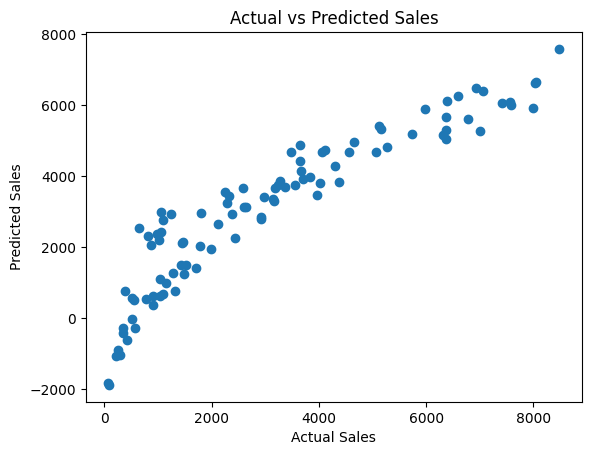

In [140]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

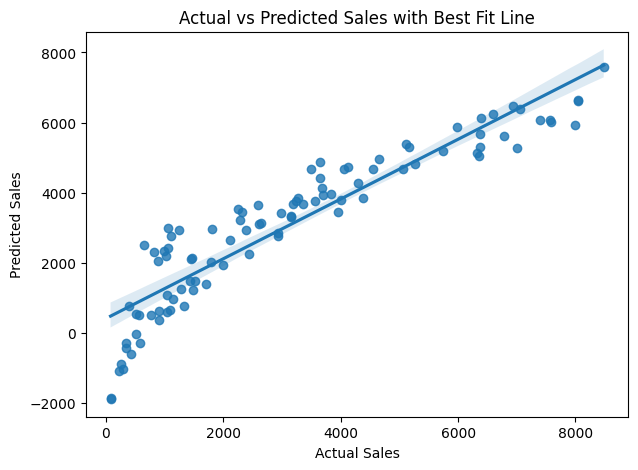

In [141]:

plt.figure(figsize=(7,5))

sns.regplot(x=y_test, y=y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales with Best Fit Line")

plt.show()

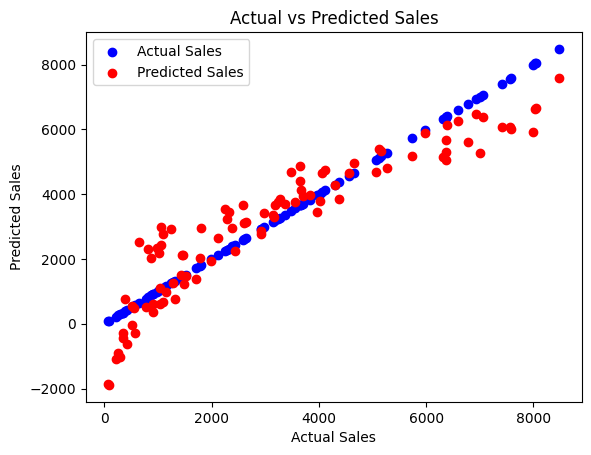

In [142]:

# Actual values (blue)
plt.scatter(y_test, y_test, color='blue', label="Actual Sales")

# Predicted values (red)
plt.scatter(y_test, y_pred, color='red', label="Predicted Sales")

# Axis labels
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

# Title
plt.title("Actual vs Predicted Sales")

# Legend to show colors
plt.legend()

plt.show()

### How to Improve the Model (Optional)

You can further improve by:

Feature engineering

Removing multicollinearity

Trying nonlinear models

Using scikit-learn models like:

Ridge Regression

Lasso Regression

Random Forest Regression

In [143]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

In [144]:

poly_model = LinearRegression()

poly_model.fit(X_poly_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [145]:
y_pred_poly = poly_model.predict(X_poly_test)

In [146]:
from sklearn.metrics import r2_score, mean_squared_error

print("Polynomial R2:", r2_score(y_test, y_pred_poly))
print("Polynomial MSE:", mean_squared_error(y_test, y_pred_poly))

Polynomial R2: 0.9703425863420629
Polynomial MSE: 164267.05165560232


Polynomial Regression performs better than Linear Regression for sales prediction. The polynomial model achieved an R² score of 0.965, meaning it explains 96.5% of the variance in sales, compared to 84.8% for the linear model. Additionally, the MSE decreased significantly from 804,610 to 184,154, indicating lower prediction error.